In [590]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [591]:
df = pd.read_csv("dirty_employee_salary_dataset.csv")  

In [592]:
df.head()

,Age,Experience,Education,JobRole,Location,Skills,CompanyType,Gender,Salary
0,36.0,15.0,Master,ML Engineer,Pune,AWS|SQL,Startup,NaN,2783653.0
1,41.0,5.0,PhD,UI/UX Designer,Pune,Python|SQL|React|CSS,Startup,Female,1560855.0
2,43.0,9.0,PhD,Data Analyst,Pune,HTML|CSS,MNC,Female,2320382.0
3,33.0,11.0,PhD,System Admin,Bangalore,HTML|Java,MNC,Male,2690016.0
4,21.0,0.0,PhD,AI Engineer,Delhi,SQL|ML,MNC,Male,1008032.0


In [593]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1050 entries, 0 to 1049
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          993 non-null    float64
 1   Experience   999 non-null    float64
 2   Education    993 non-null    object 
 3   JobRole      1007 non-null   object 
 4   Location     1003 non-null   object 
 5   Skills       1000 non-null   object 
 6   CompanyType  1011 non-null   object 
 7   Gender       995 non-null    object 
 8   Salary       998 non-null    float64
dtypes: float64(3), object(6)
memory usage: 74.0+ KB


In [594]:
df.describe()

,Age,Experience,Salary
count,993.000000,999.000000,9.980000e+02
mean,36.876007,6.374771,1.617160e+06
std,15.183768,7.961358,1.267801e+06
min,21.000000,0.000000,1.821170e+05
25%,28.000000,1.000000,9.037680e+05
50%,35.000000,4.000000,1.314870e+06
75%,43.000000,9.000000,2.066922e+06
max,121.994036,51.066497,8.738394e+06


In [595]:
df.dtypes

Age            float64
Experience     float64
Education       object
JobRole         object
Location        object
Skills          object
CompanyType     object
Gender          object
Salary         float64
dtype: object

Handling missing values

In [596]:
df.isnull().sum()

Age            57
Experience     51
Education      57
JobRole        43
Location       47
Skills         50
CompanyType    39
Gender         55
Salary         52
dtype: int64

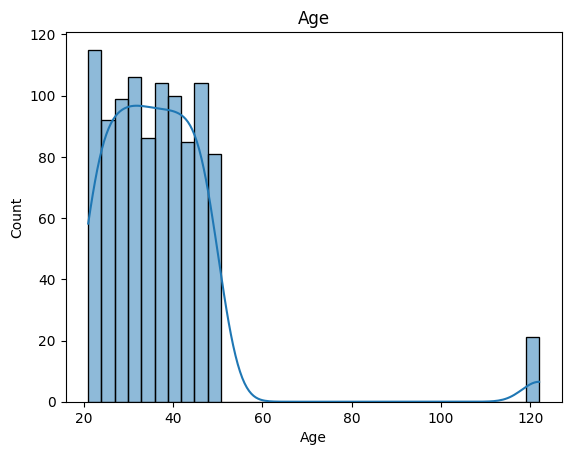

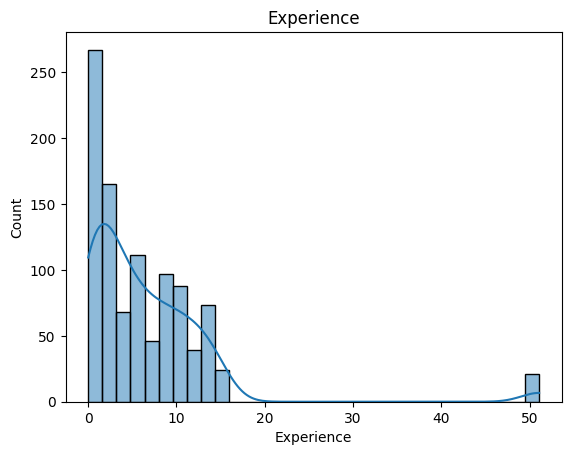

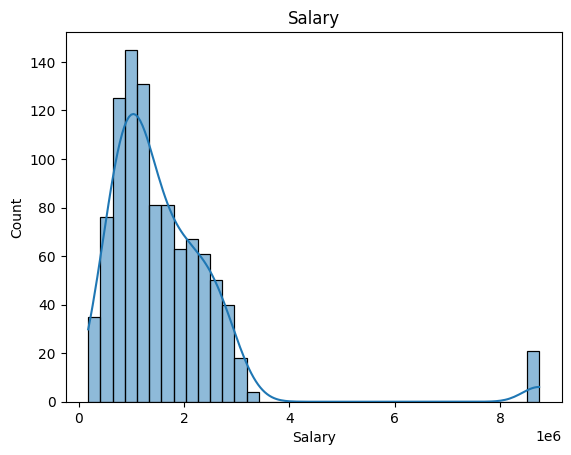

In [597]:
for col in ['Age', 'Experience', 'Salary']:
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

In [598]:
for col in ['Age', 'Experience', 'Salary']:
    skew = df[col].skew()
    
    if skew > 0.5 or skew < -0.5:
        df[col] = df[col].fillna(df[col].median())
    else:
        df[col] = df[col].fillna(df[col].mean())

In [599]:
cols = ['Education', 'JobRole', 'Location', 'Skills', 'CompanyType', 'Gender']

for col in cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [600]:
print(df.isnull().sum())

Age            0
Experience     0
Education      0
JobRole        0
Location       0
Skills         0
CompanyType    0
Gender         0
Salary         0
dtype: int64


Removing Duplicates

In [601]:
df.duplicated().sum()

np.int64(42)

In [602]:
df.drop_duplicates(inplace=True)

In [603]:
df.duplicated().sum()

np.int64(0)

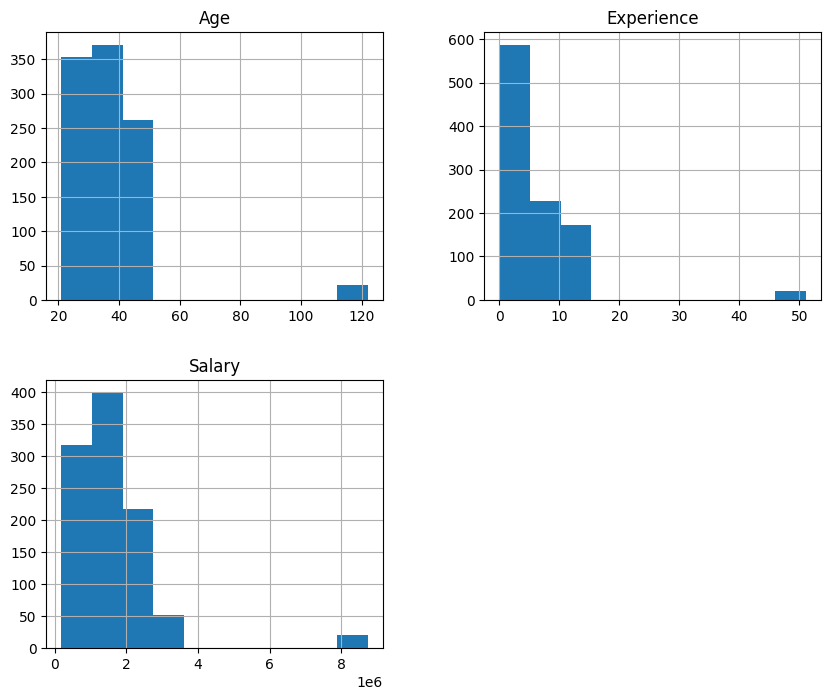

In [604]:
df.hist(figsize=(10,8))
plt.show()

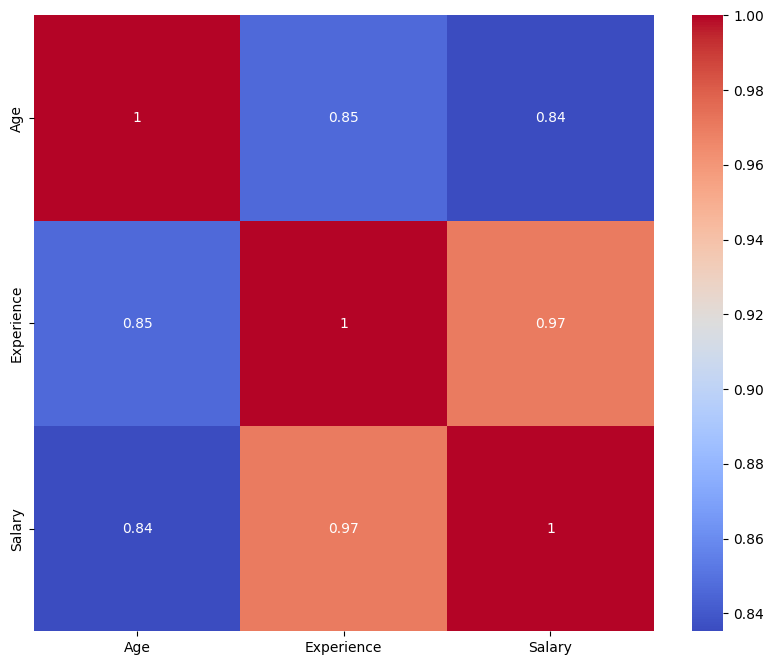

In [605]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

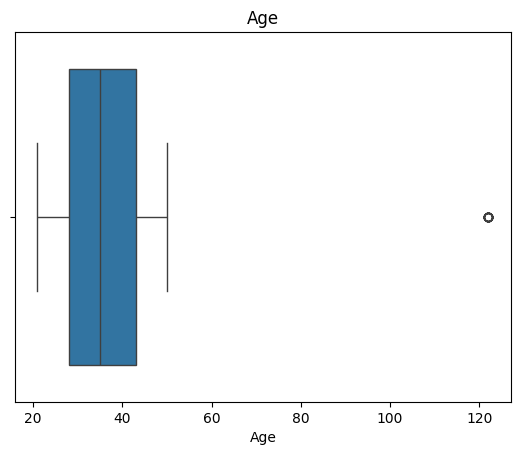

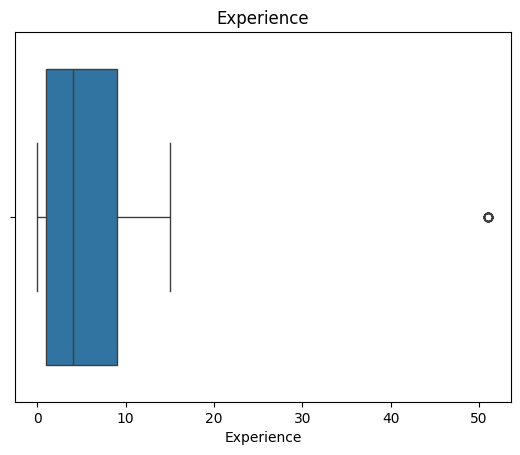

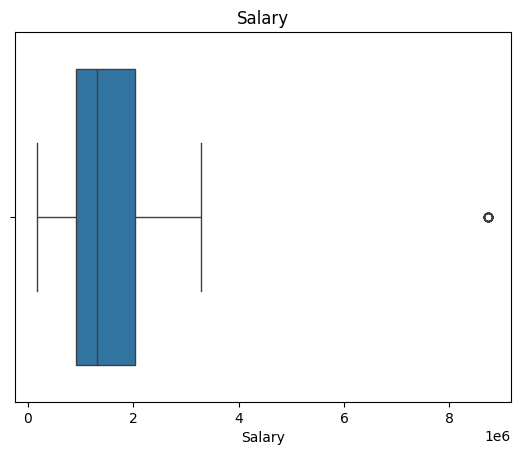

In [606]:
for col in df.select_dtypes(include=['int64','float64']).columns:
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

Removing the Outliers

In [607]:
num_cols = ['Age', 'Experience', 'Salary']

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)

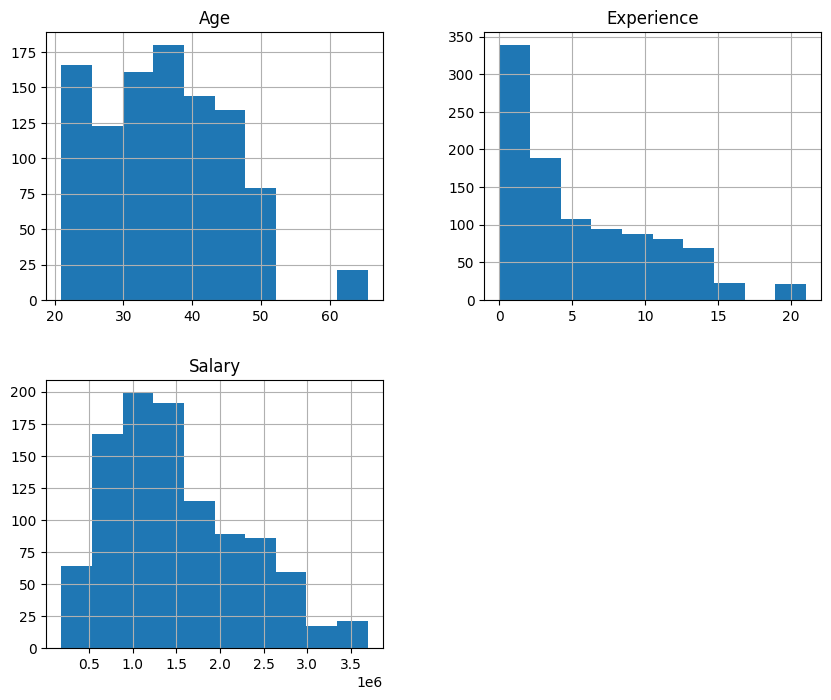

In [608]:
df.hist(figsize=(10,8))
plt.show()

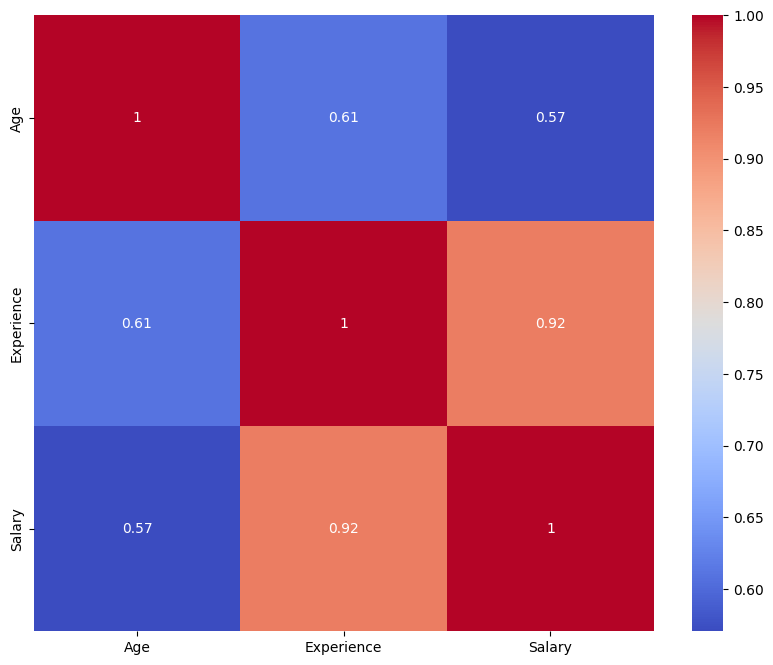

In [609]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

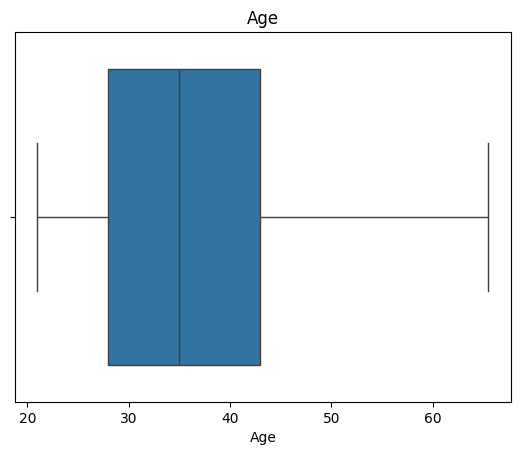

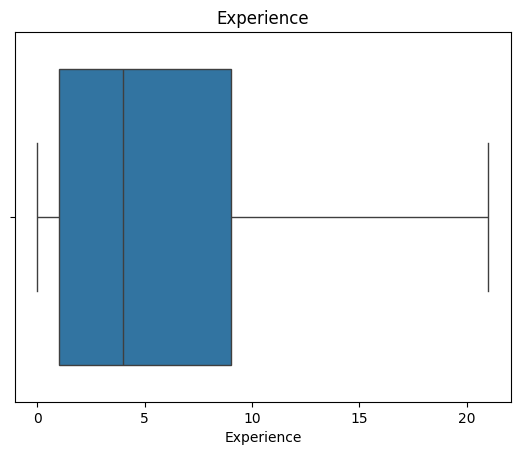

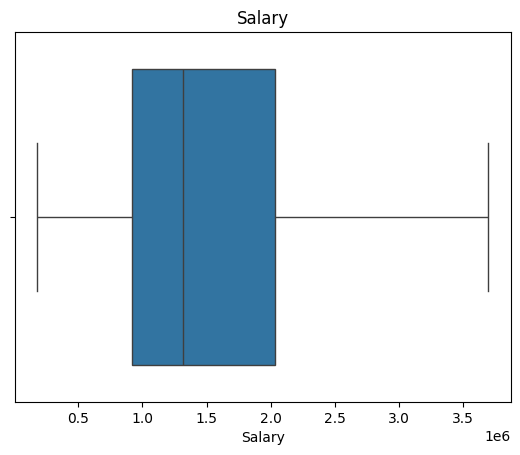

In [610]:
for col in df.select_dtypes(include=['int64','float64']).columns:
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()


In [611]:
df['skill_count'] = df['Skills'].apply(lambda x: len(str(x).split('|')))
df.drop('Skills', axis=1, inplace=True)

In [612]:
df.head()

,Age,Experience,Education,JobRole,Location,CompanyType,Gender,Salary,skill_count
0,36.0,15.0,Master,ML Engineer,Pune,Startup,Female,2783653.0,2
1,41.0,5.0,PhD,UI/UX Designer,Pune,Startup,Female,1560855.0,4
2,43.0,9.0,PhD,Data Analyst,Pune,MNC,Female,2320382.0,2
3,33.0,11.0,PhD,System Admin,Bangalore,MNC,Male,2690016.0,2
4,21.0,0.0,PhD,AI Engineer,Delhi,MNC,Male,1008032.0,2


In [613]:
def exp_level(x):
    if x < 2:
        return 'Fresher'
    elif x < 5:
        return 'Junior'
    elif x < 10:
        return 'Mid'
    else:
        return 'Senior'

df['exp_level'] = df['Experience'].apply(exp_level)

In [614]:
df.head()

,Age,Experience,Education,JobRole,Location,CompanyType,Gender,Salary,skill_count,exp_level
0,36.0,15.0,Master,ML Engineer,Pune,Startup,Female,2783653.0,2,Senior
1,41.0,5.0,PhD,UI/UX Designer,Pune,Startup,Female,1560855.0,4,Mid
2,43.0,9.0,PhD,Data Analyst,Pune,MNC,Female,2320382.0,2,Mid
3,33.0,11.0,PhD,System Admin,Bangalore,MNC,Male,2690016.0,2,Senior
4,21.0,0.0,PhD,AI Engineer,Delhi,MNC,Male,1008032.0,2,Fresher


In [615]:
df['Gender'] = df['Gender'].str.lower().str.strip()

df['Gender'] = df['Gender'].replace('nan', np.nan)

df['Gender'] = df['Gender'].fillna('unknown')

In [616]:
print(df['Gender'].unique())

['female' 'male' 'unknown']


In [617]:
df['Education'] = df['Education'].str.lower().str.strip()

In [618]:
df['Education'] = df['Education'].replace({
    'bachelors': 'bachelor',
    'master': 'masters',
    'msc': 'masters',
    'phd': 'phd',
    'ph.d': 'phd',
    'nan': np.nan,
    'na': np.nan
})

In [619]:
df['Education'] = df['Education'].fillna('unknown')

In [620]:
print(df['Education'].unique())

['masters' 'phd' 'bachelor' 'unknown']


In [621]:
df['JobRole'] = df['JobRole'].str.lower().str.strip()
df['CompanyType'] = df['CompanyType'].str.lower().str.strip()
df['Location'] = df['Location'].str.lower().str.strip()

In [622]:
cat_cols = df.select_dtypes(include='object').columns
print(cat_cols)

Index(['Education', 'JobRole', 'Location', 'CompanyType', 'Gender',
       'exp_level'],
      dtype='object')


In [623]:
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

In [624]:
corr = df.corr(numeric_only=True)

corr_target = corr['Salary'].abs()

selected_features = corr_target[corr_target > 0.05].index

df = df[selected_features]

In [625]:
df.head()

,Age,Experience,Salary,Education_phd,Education_unknown,JobRole_nan,JobRole_software engineer,JobRole_web developer,Location_pune,CompanyType_nan,CompanyType_startup,exp_level_Junior,exp_level_Mid,exp_level_Senior
0,36.0,15.0,2783653.0,False,False,False,False,False,True,False,True,False,False,True
1,41.0,5.0,1560855.0,True,False,False,False,False,True,False,True,False,True,False
2,43.0,9.0,2320382.0,True,False,False,False,False,True,False,False,False,True,False
3,33.0,11.0,2690016.0,True,False,False,False,False,False,False,False,False,False,True
4,21.0,0.0,1008032.0,True,False,False,False,False,False,False,False,False,False,False


In [626]:
df.shape

(1008, 14)

In [627]:
df = df.astype(int)

In [628]:
df.head()

,Age,Experience,Salary,Education_phd,Education_unknown,JobRole_nan,JobRole_software engineer,JobRole_web developer,Location_pune,CompanyType_nan,CompanyType_startup,exp_level_Junior,exp_level_Mid,exp_level_Senior
0,36,15,2783653,0,0,0,0,0,1,0,1,0,0,1
1,41,5,1560855,1,0,0,0,0,1,0,1,0,1,0
2,43,9,2320382,1,0,0,0,0,1,0,0,0,1,0
3,33,11,2690016,1,0,0,0,0,0,0,0,0,0,1
4,21,0,1008032,1,0,0,0,0,0,0,0,0,0,0


In [629]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()


df[['Age', 'Experience']] = scaler.fit_transform(df[['Age', 'Experience']])

In [630]:
df[['Age']].head()

,Age
0,0.340909
1,0.454545
2,0.500000
3,0.272727
4,0.000000


In [631]:
df[['Experience']].head()

,Experience
0,0.714286
1,0.238095
2,0.428571
3,0.523810
4,0.000000


In [632]:
df.head()

,Age,Experience,Salary,Education_phd,Education_unknown,JobRole_nan,JobRole_software engineer,JobRole_web developer,Location_pune,CompanyType_nan,CompanyType_startup,exp_level_Junior,exp_level_Mid,exp_level_Senior
0,0.340909,0.714286,2783653,0,0,0,0,0,1,0,1,0,0,1
1,0.454545,0.238095,1560855,1,0,0,0,0,1,0,1,0,1,0
2,0.500000,0.428571,2320382,1,0,0,0,0,1,0,0,0,1,0
3,0.272727,0.523810,2690016,1,0,0,0,0,0,0,0,0,0,1
4,0.000000,0.000000,1008032,1,0,0,0,0,0,0,0,0,0,0


In [633]:
df.dtypes

Age                          float64
Experience                   float64
Salary                         int64
Education_phd                  int64
Education_unknown              int64
JobRole_nan                    int64
JobRole_software engineer      int64
JobRole_web developer          int64
Location_pune                  int64
CompanyType_nan                int64
CompanyType_startup            int64
exp_level_Junior               int64
exp_level_Mid                  int64
exp_level_Senior               int64
dtype: object

In [634]:
# done 

In [635]:
X = df.drop('Salary', axis=1)
y = df['Salary']

In [636]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [637]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [638]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [639]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [640]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,        # more trees → better learning
    max_depth=15,            # control overfitting
    min_samples_split=5,     # avoid too complex trees
    min_samples_leaf=2,      # smoother predictions
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)




In [641]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [642]:
def evaluate(y_test, y_pred):
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("MSE:", mean_squared_error(y_test, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
    print("R2 Score:", r2_score(y_test, y_pred))
    print("-" * 40)

In [643]:
print("Linear Regression")
evaluate(y_test, y_pred_lr)

print("Decision Tree")
evaluate(y_test, y_pred_dt)

print("Random Forest")
evaluate(y_test, y_pred_rf)

Linear Regression
MAE: 154229.3981742899
MSE: 64282016958.85134
RMSE: 253538.9850868133
R2 Score: 0.8952254523071332
----------------------------------------
Decision Tree
MAE: 219768.17821782178
MSE: 117014173398.03629
RMSE: 342073.34505634353
R2 Score: 0.8092762537416652
----------------------------------------
Random Forest
MAE: 169444.7023513583
MSE: 70691017633.3319
RMSE: 265877.8246363015
R2 Score: 0.8847792936674344
----------------------------------------


In [644]:
best_model = lr

In [645]:
sample = X_test[0].reshape(1, -1)

prediction = best_model.predict(sample)

print("Predicted Salary:", prediction[0])
print("Actual Salary:", y_test.iloc[0])

Predicted Salary: 888745.3676200066
Actual Salary: 1032293


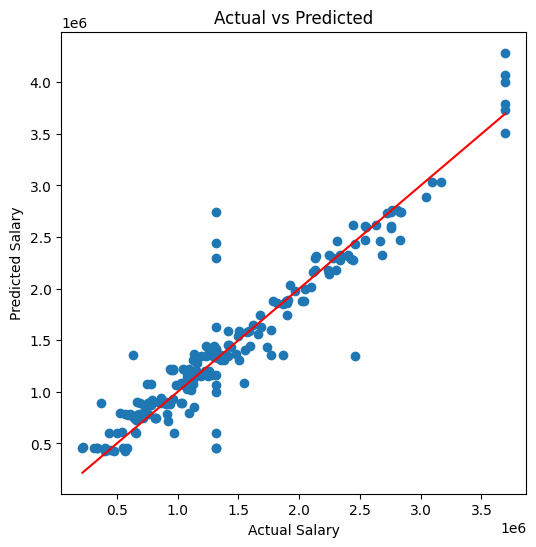

In [646]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_lr)

# perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted")
plt.show()

In [647]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(lr, X, y, cv=5, scoring='r2')

print("Average R2:", scores.mean())

Average R2: 0.904293186584758


In [648]:
actual = y_test.iloc[0]
pred = prediction[0]

error = abs(pred - actual)
percent_error = (error / actual) * 100

print("Prediction Error:", error)
print("Percentage Error: {:.2f}%".format(percent_error))

Prediction Error: 143547.63237999345
Percentage Error: 13.91%


In [649]:
print("Cross Validation Scores:", scores)
print("Average R2:", scores.mean())
print("Std Dev:", scores.std())

Cross Validation Scores: [0.89347914 0.89181552 0.9231445  0.91325494 0.89977184]
Average R2: 0.904293186584758
Std Dev: 0.012072806677300391


In [650]:
print("Final Model: Linear Regression")
print("Test R2 Score:", r2_score(y_test, y_pred_lr))
print("Cross Validation R2:", scores.mean())
print("Conclusion: Model performs well with strong linear relationship in data.")

Final Model: Linear Regression
Test R2 Score: 0.8952254523071332
Cross Validation R2: 0.904293186584758
Conclusion: Model performs well with strong linear relationship in data.
